# Music Classification — Unsupervised + Supervised

Vertrekt vanuit `combined.csv` en classificeert songs zonder vooraf gedefinieerde labels.

**Aanpak:**
1. **K-Means clustering** — groepeert songs op basis van audio features (unsupervised)
2. **Random Forest classifier** — getraind op de K-Means clusters als labels (supervised)

Na afloop interpreteer je welke cluster 'calm', 'neutral' en 'energy' is op basis van de cluster-gemiddelden.

---

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import os
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42

In [2]:
os.getcwd()


'c:\\Users\\astri\\Desktop\\Data_Scientist\\Eindwerk\\spotify-project\\notebooks'

---
## 2. Instellingen

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
#  PAD
# ══════════════════════════════════════════════════════════════════════════════
PARTICIPANT = "courgette"
CSV_PATH = Path(f"../data/playlists/{PARTICIPANT}/playlists_generated/combined.csv")   

# ══════════════════════════════════════════════════════════════════════════════
#  FEATURES die gebruikt worden voor clustering & classificatie
#  Verwijder features die niet in jouw CSV staan
# ══════════════════════════════════════════════════════════════════════════════
FEATURES = [
    'tempo',
    'energy',
    'acousticness',
    'valence',
    'loudness',
    'danceability',
    'instrumentalness',
    'speechiness',
]

# ══════════════════════════════════════════════════════════════════════════════
#  CLUSTERING
# ══════════════════════════════════════════════════════════════════════════════
N_CLUSTERS = 8

# ══════════════════════════════════════════════════════════════════════════════
#  RANDOM FOREST
# ══════════════════════════════════════════════════════════════════════════════
N_ESTIMATORS = 200    # aantal bomen
TEST_SIZE    = 0.25   # 25% voor testen

print("Instellingen geladen OK")


Instellingen geladen OK


---
## 3. Data laden & voorbereiden

In [4]:
df = pd.read_csv(CSV_PATH)
print(f"Geladen: {len(df)} songs")
print(f"Kolommen: {list(df.columns)}")

# Alleen features behouden die aanwezig zijn in de CSV
features_available = [f for f in FEATURES if f in df.columns]
missing = [f for f in FEATURES if f not in df.columns]
if missing:
    print(f"\nNiet gevonden in CSV (worden genegeerd): {missing}")
print(f"Gebruikte features: {features_available}")

# Rijen met NaN verwijderen
df_model = df[features_available].dropna()
dropped = len(df) - len(df_model)
if dropped:
    print(f"Verwijderd wegens NaN: {dropped} rijen")
print(f"\nBeschikbaar voor modellen: {len(df_model)} songs")

# Normaliseren (belangrijk voor K-Means en PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)
print("Features genormaliseerd (StandardScaler) OK")

Geladen: 5720 songs
Kolommen: ['uri', 'name', 'album', 'artists', 'Release Date', 'duration_ms', 'Popularity', 'Explicit', 'Added By', 'Added At', 'Genres', 'Record Label', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
Gebruikte features: ['tempo', 'energy', 'acousticness', 'valence', 'loudness', 'danceability', 'instrumentalness', 'speechiness']

Beschikbaar voor modellen: 5720 songs
Features genormaliseerd (StandardScaler) OK


---
## 4. Model A — K-Means Clustering
Groepeert songs puur op basis van audio features, zonder labels.

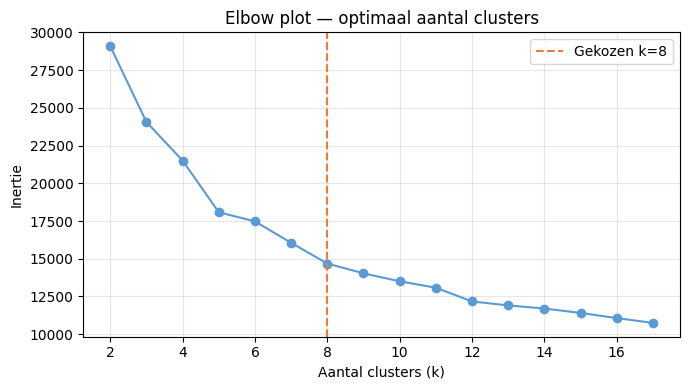

In [5]:
# ── Elbow plot: inertie per aantal clusters ───────────────────────────────────
inertias = []
k_range = range(2, 18)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertias, marker='o', color='#5b9bd5')
ax.axvline(N_CLUSTERS, color='#ed7d31', linestyle='--', label=f'Gekozen k={N_CLUSTERS}')
ax.set_xlabel('Aantal clusters (k)')
ax.set_ylabel('Inertie')
ax.set_title('Elbow plot — optimaal aantal clusters')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# ── K-Means trainen ───────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init='auto')
cluster_labels = kmeans.fit_predict(X_scaled)

df_model = df_model.copy()
df_model['cluster'] = cluster_labels

# Aantal songs per cluster
counts = df_model['cluster'].value_counts().sort_index()
for c, n in counts.items():
    print(f"  Cluster {c}: {n} songs")

  Cluster 0: 1379 songs
  Cluster 1: 678 songs
  Cluster 2: 874 songs
  Cluster 3: 1033 songs
  Cluster 4: 361 songs
  Cluster 5: 517 songs
  Cluster 6: 583 songs
  Cluster 7: 295 songs


In [7]:
# ── Cluster gemiddelden — interpreteer welke cluster calm/neutral/energy is ───
cluster_means = df_model.groupby('cluster')[features_available].mean().round(3)
print("Gemiddelde waarden per cluster:")
display(cluster_means)

print("\nTip: cluster met laagste tempo + energie = calm")
print("     cluster met hoogste tempo + energie = energy")
print("     middelste cluster = neutral")

Gemiddelde waarden per cluster:


,tempo,energy,acousticness,valence,loudness,danceability,instrumentalness,speechiness
cluster,,,,,,,,
0,116.988,0.716,0.180,0.770,-7.172,0.713,0.031,0.054
1,91.428,0.346,0.698,0.341,-11.071,0.518,0.034,0.040
2,102.339,0.067,0.952,0.192,-26.623,0.355,0.880,0.047
3,112.292,0.728,0.103,0.375,-6.309,0.582,0.027,0.051
4,121.917,0.660,0.277,0.423,-9.616,0.633,0.791,0.050
5,162.866,0.807,0.098,0.563,-5.744,0.464,0.030,0.072
6,141.769,0.348,0.686,0.322,-11.088,0.500,0.049,0.040
7,116.882,0.699,0.169,0.576,-6.960,0.702,0.036,0.267



Tip: cluster met laagste tempo + energie = calm
     cluster met hoogste tempo + energie = energy
     middelste cluster = neutral


In [8]:
# Normalize cluster means to [0,1] before scoring (fixes scale mismatch)
from sklearn.preprocessing import MinMaxScaler

score_cols = ['tempo', 'energy', 'loudness', 'acousticness']
_scaler = MinMaxScaler()
cm_norm = pd.DataFrame(
    _scaler.fit_transform(cluster_means[score_cols]),
    index=cluster_means.index,
    columns=score_cols
)

# Arousal score: high tempo/energy/loudness = more energetic; high acousticness = calmer
cm_norm["arousal_score"] = (
    0.35 * cm_norm["energy"] +
    0.35 * cm_norm["tempo"] +
    0.20 * cm_norm["loudness"] +
   -0.10 * cm_norm["acousticness"]
)

# Threshold-based assignment on normalized [0,1] score
def score_to_label(score):
    if score < 0.33:
        return "calm"
    elif score > 0.66:
        return "energy"
    else:
        return "others"

arousal = {cluster: score_to_label(cm_norm.loc[cluster, "arousal_score"])
           for cluster in cm_norm.index}

df_model["arousal"] = df_model["cluster"].map(arousal)

print("Cluster -> arousal mapping:")
for c in sorted(arousal):
    print(f"  Cluster {c}  score={cm_norm.loc[c,'arousal_score']:.2f}  -> {arousal[c]}")
print()
print(df_model["arousal"].value_counts().to_string())

Cluster -> arousal mapping:
  Cluster 0  score=0.61  -> others
  Cluster 1  score=0.21  -> calm
  Cluster 2  score=-0.05  -> calm
  Cluster 3  score=0.61  -> others
  Cluster 4  score=0.57  -> others
  Cluster 5  score=0.90  -> energy
  Cluster 6  score=0.46  -> others
  Cluster 7  score=0.60  -> others

arousal
others    3651
calm      1552
energy     517


PCA verklaart 49.2% + 13.0% = 62.2% van de variantie


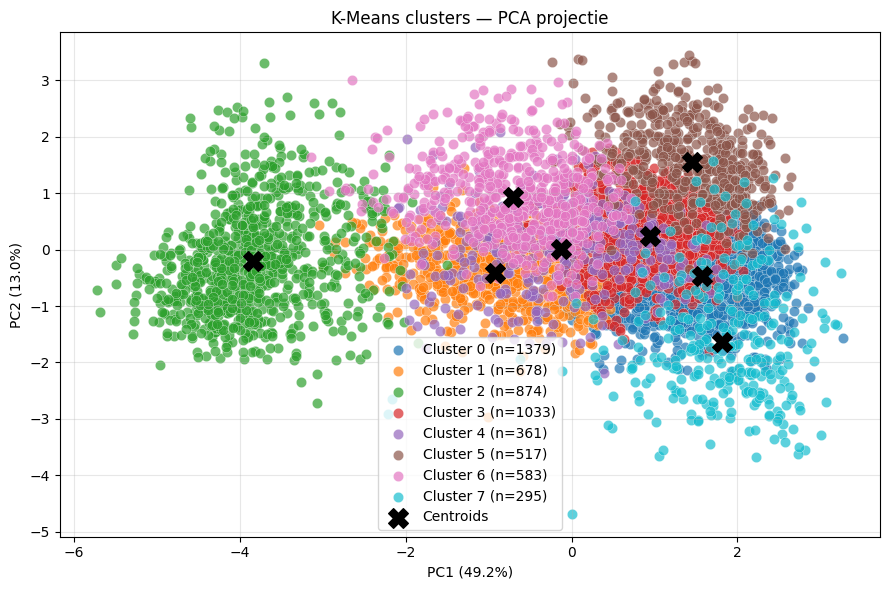

In [9]:
# ── PCA visualisatie (2D projectie van alle features) ────────────────────────
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f"PCA verklaart {explained[0]*100:.1f}% + {explained[1]*100:.1f}% = {sum(explained)*100:.1f}% van de variantie")

colors = [
    '#1f77b4',  # helder blauw
    '#ff7f0e',  # oranje
    '#2ca02c',  # groen
    '#d62728',  # rood
    '#9467bd',  # paars
    '#8c564b',  # bruin
    '#e377c2',  # roze
    '#17becf'   # cyaan/turquoise
]


fig, ax = plt.subplots(figsize=(9, 6))
for c in range(N_CLUSTERS):
    mask = cluster_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=colors[c], label=f'Cluster {c} (n={mask.sum()})',
               alpha=0.7, edgecolors='white', linewidths=0.3, s=55)

# Cluster centers
centers_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
           marker='X', s=200, color='black', zorder=5, label='Centroids')

ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.set_title('K-Means clusters — PCA projectie')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
pca.explained_variance_ratio_

array([0.4920435, 0.1296069])

In [11]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=features_available
)

print("\nPCA Loadings:")
print(loadings)


PCA Loadings:
                       PC1       PC2
tempo             0.158736  0.714674
energy            0.456340  0.121093
acousticness     -0.431476 -0.094310
valence           0.337342 -0.267342
loudness          0.451233  0.138516
danceability      0.325920 -0.481427
instrumentalness -0.370271 -0.073557
speechiness       0.140177 -0.371271


In [12]:
for pc in loadings.columns:
    print(f"\nBelangrijkste features voor {pc}:")
    print(loadings[pc].abs().sort_values(ascending=False).head(5))



Belangrijkste features voor PC1:
energy              0.456340
loudness            0.451233
acousticness        0.431476
instrumentalness    0.370271
valence             0.337342
Name: PC1, dtype: float64

Belangrijkste features voor PC2:
tempo           0.714674
danceability    0.481427
speechiness     0.371271
valence         0.267342
loudness        0.138516
Name: PC2, dtype: float64


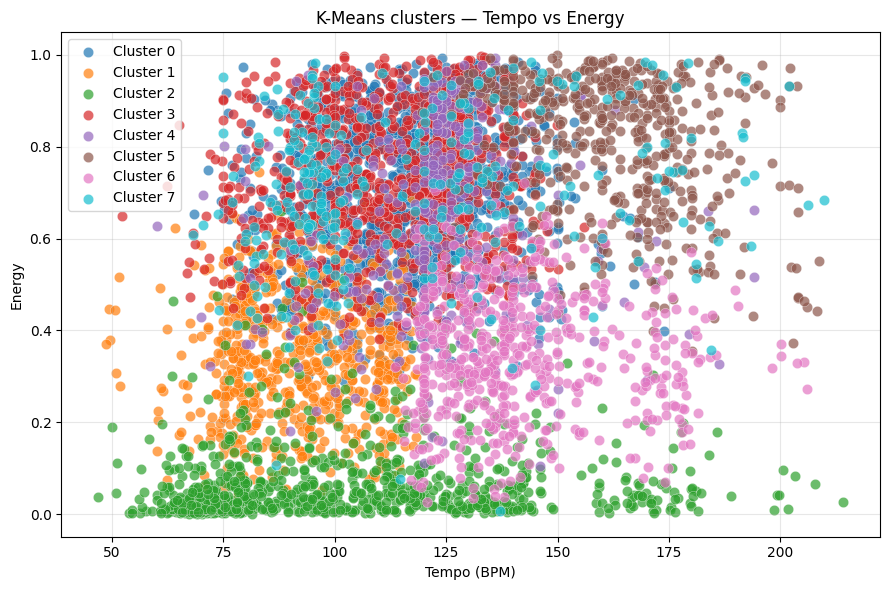

In [13]:
# ── Scatter: Tempo vs Energy ingekleurd per cluster ───────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
for c in range(N_CLUSTERS):
    mask = df_model['cluster'] == c
    ax.scatter(df_model.loc[mask, 'tempo'], df_model.loc[mask, 'energy'],
               color=colors[c], label=f'Cluster {c}',
               alpha=0.7, edgecolors='white', linewidths=0.3, s=55)

ax.set_xlabel('Tempo (BPM)')
ax.set_ylabel('Energy')
ax.set_title('K-Means clusters — Tempo vs Energy')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Cluster labels interpreteren
Vul hier in welke cluster calm, neutral en energy is op basis van de gemiddelden hierboven.

In [14]:
# Gebruik de automatische arousal-mapping uit de vorige cel
CLUSTER_NAMES = arousal   # dict: {cluster_int -> 'calm' / 'energy' / 'others'}

df_model['label'] = df_model['cluster'].map(CLUSTER_NAMES)

# Voeg naam kolommen toe aan het originele dataframe
df_result = df.loc[df_model.index].copy()
df_result['cluster'] = df_model['cluster']
df_result['label']   = df_model['label']

print("Songs per label:")
print(df_result['label'].value_counts().to_string())

# Preview
show_cols = [c for c in ['name', 'artists', 'tempo', 'energy', 'label'] if c in df_result.columns]
display(df_result[show_cols].head(10))

Songs per label:
label
others    3651
calm      1552
energy     517


,name,artists,tempo,energy,label
0,exile (feat. Bon Iver),Taylor Swift;Bon Iver,75.602,0.380,calm
1,The Light Upon Us,Talos,95.133,0.640,calm
2,Shine,Benjamin Francis Leftwich,118.067,0.512,others
3,Voilà,Barbara Pravi,135.379,0.337,others
4,Sleeptalking,Nona,106.612,0.245,calm
5,Is There Something in the Movies?,Samia,110.306,0.101,calm
6,Riptide,Vance Joy,101.654,0.731,others
7,Celeste,Ezra Vine,138.976,0.841,energy
8,Hold My Girl,George Ezra,121.941,0.527,others
9,Glamour Child,Moonrise Nation,114.950,0.583,others


---
## 6. Model B — Random Forest Classifier
Getraind op de K-Means cluster labels. Leert welke combinatie van features een cluster voorspelt.

In [15]:
# ── Train/test split ──────────────────────────────────────────────────────────
X = df_model[features_available].values
y = df_model['cluster'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_train)} songs")
print(f"Test : {len(X_test)} songs")

Train: 4290 songs
Test : 1430 songs


In [16]:
# ── Random Forest trainen ─────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Cross-validatie score
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print(f"Cross-validatie accuracy (5-fold): {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

# Test score
y_pred = rf.predict(X_test)
print(f"Test accuracy                     : {(y_pred == y_test).mean():.3f}")

Cross-validatie accuracy (5-fold): 0.941 +/- 0.007
Test accuracy                     : 0.936


In [17]:
# ── Classification report ─────────────────────────────────────────────────────
label_names = [CLUSTER_NAMES[i] for i in sorted(CLUSTER_NAMES)]
print(classification_report(y_test, y_pred, target_names=label_names))

              precision    recall  f1-score   support

      others       0.94      0.95      0.95       345
        calm       0.98      0.93      0.95       170
        calm       0.96      0.99      0.97       218
      others       0.91      0.93      0.92       258
      others       0.92      0.93      0.93        90
      energy       0.91      0.89      0.90       129
      others       0.91      0.86      0.89       146
      others       0.97      0.93      0.95        74

    accuracy                           0.94      1430
   macro avg       0.94      0.93      0.93      1430
weighted avg       0.94      0.94      0.94      1430



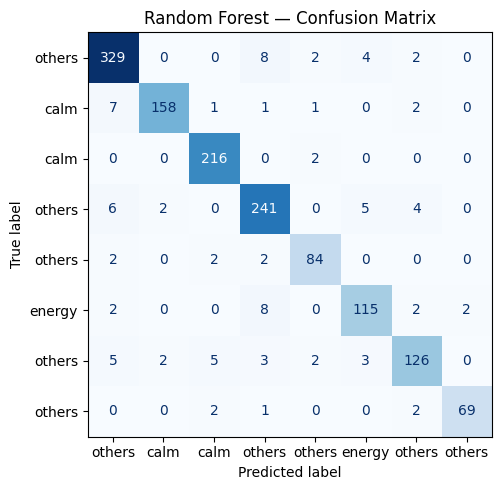

In [18]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

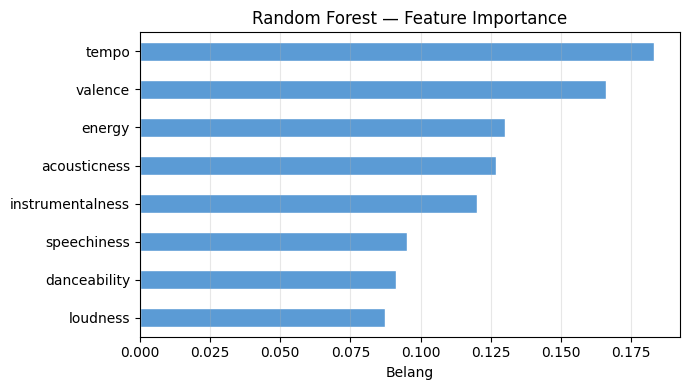


Meest bepalende features:
tempo               0.183196
valence             0.166133
energy              0.130105
acousticness        0.126675
instrumentalness    0.120142
speechiness         0.095161
danceability        0.091209
loudness            0.087377


In [19]:
# ── Feature importance ────────────────────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=features_available).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind='barh', ax=ax, color='#5b9bd5', edgecolor='white')
ax.set_xlabel('Belang')
ax.set_title('Random Forest — Feature Importance')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nMeest bepalende features:")
print(importances.sort_values(ascending=False).to_string())

---
## 7. Vergelijking K-Means vs Random Forest

In [20]:
# Beide modellen voorspellen op de volledige dataset
df_compare = df_model[features_available].copy()
df_compare['kmeans_cluster'] = cluster_labels
df_compare['rf_cluster']     = rf.predict(X_scaled)
df_compare['kmeans_label']   = df_compare['kmeans_cluster'].map(CLUSTER_NAMES)
df_compare['rf_label']       = df_compare['rf_cluster'].map(CLUSTER_NAMES)
df_compare['agree']          = df_compare['kmeans_cluster'] == df_compare['rf_cluster']

agreement = df_compare['agree'].mean()
print(f"Overeenstemming K-Means vs Random Forest: {agreement*100:.1f}%")
print(f"Verschillend geclassificeerd            : {(~df_compare['agree']).sum()} songs")

# Songs waar de twee modellen het oneens zijn
disagreed = df_compare[~df_compare['agree']]
show = [c for c in ['name', 'artists', 'tempo', 'energy', 'kmeans_label', 'rf_label'] if c in df_result.columns or c in disagreed.columns]

if len(disagreed) > 0:
    print(f"\nVoorbeeld van songs waarover de modellen verschillen:")
    combined_view = df_result.loc[disagreed.index, [c for c in ['name','artists','tempo','energy'] if c in df_result.columns]]
    combined_view = combined_view.join(disagreed[['kmeans_label','rf_label']])
    display(combined_view.head(10))

Overeenstemming K-Means vs Random Forest: 57.3%
Verschillend geclassificeerd            : 2445 songs

Voorbeeld van songs waarover de modellen verschillen:


,name,artists,tempo,energy,kmeans_label,rf_label
2,Shine,Benjamin Francis Leftwich,118.067,0.512,others,calm
3,Voilà,Barbara Pravi,135.379,0.337,others,calm
7,Celeste,Ezra Vine,138.976,0.841,energy,others
8,Hold My Girl,George Ezra,121.941,0.527,others,calm
9,Glamour Child,Moonrise Nation,114.950,0.583,others,calm
11,Still,Seinabo Sey,168.937,0.270,others,calm
12,Still Life,Henry Jamison;JOSEPH,132.082,0.541,others,calm
13,Ain't Gonna Let You Drown,Júníus Meyvant,139.915,0.448,others,calm
14,Tiger Striped Sky,Roo Panes,139.899,0.317,others,calm
15,Don't Start Now,Dua Lipa,123.941,0.793,others,others


---
## 8. Resultaten opslaan

In [21]:
OUTPUT_PATH = Path(f"../data/playlists/{PARTICIPANT}/playlist_ml/classified_songs.csv")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

df_result.to_csv(OUTPUT_PATH, index=False)
print(f"Opgeslagen: {OUTPUT_PATH}")
print(f"  {len(df_result)} songs met kolommen 'cluster' en 'label'")
print(f"\nVerdeling:")
print(df_result['label'].value_counts().to_string())


Opgeslagen: ..\data\playlists\courgette\playlist_ml\classified_songs.csv
  5720 songs met kolommen 'cluster' en 'label'

Verdeling:
label
others    3651
calm      1552
energy     517
